# Notebook 4 — Ensemble Blending and Evaluation

**MediShift · Forecasting Engine, Bringing It Together**

Notebooks 1–3 fitted three independent models — Ridge Regression, Gradient-
Boosted Stumps, and Holt-Winters — on the same 3-year shift dataset, each with
its own strength: Ridge Regression is transparent and stable, boosted stumps
can pick up threshold-style interactions a straight line cannot, and
Holt-Winters models the calendar directly. This notebook implements report
**Section 2.5**: rather than trust any one of them, or split the vote evenly,
MediShift weights each fitted model by *its own held-out accuracy*, blends
that weighted vote with a fast heuristic fallback, and evaluates the result
against every individual model on the same held-out shifts.

**What this notebook covers**

1. Load the three models' held-out predictions (saved by Notebooks 1–3)
2. Derive the inverse-MAE ensemble weights (Equation 2.8)
3. Implement the heuristic fallback forecast the blend leans on
4. Blend all four signals (Equation 2.9) and evaluate against every individual model
5. Derive the day-of-week adjustment factor $\phi_d$ (Equation 2.10)
6. Produce one full roster week of blended forecasts (Equation 2.11) — the actual number Chapter 3's staffing model consumes
7. Recap the full forecasting pipeline (report Figure 2.1 / Algorithm 2.1)

## 1. Setup & Load Each Model's Held-Out Predictions

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.edgecolor"] = "#52514E"
plt.rcParams["axes.labelcolor"] = "#0B0B0B"
plt.rcParams["text.color"] = "#0B0B0B"
plt.rcParams["xtick.color"] = "#52514E"
plt.rcParams["ytick.color"] = "#52514E"

C = {
    "blue": "#2A78D6", "orange": "#EB6834", "aqua": "#1BAF7A",
    "yellow": "#EDA100", "violet": "#4A3AA7", "ink": "#0B0B0B",
    "muted": "#898781", "hair": "#E1E0D9", "surface": "#FCFCFB",
}
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

ridge_pred = pd.read_csv("artifacts/ridge_predictions.csv", parse_dates=["date"])
boosted_pred = pd.read_csv("artifacts/boosted_predictions.csv", parse_dates=["date"])
holt_pred = pd.read_csv("artifacts/holt_predictions.csv", parse_dates=["date"])

# Sanity check: all three notebooks used the identical chronological 80/20
# split, so every row should line up exactly on (date, shift_type, y_true).
assert (ridge_pred["date"] == boosted_pred["date"]).all()
assert (ridge_pred["date"] == holt_pred["date"]).all()
assert (ridge_pred["shift_type"] == boosted_pred["shift_type"]).all()
assert (ridge_pred["y_true"].values == boosted_pred["y_true"].values).all()
assert (ridge_pred["y_true"].values == holt_pred["y_true"].values).all()

merged = ridge_pred.rename(columns={"y_pred_ridge": "ridge"}).copy()
merged["boosted"] = boosted_pred["y_pred_boosted"].values
merged["holt"] = holt_pred["y_pred_holt"].values

print(f"{len(merged):,} held-out shifts, all three models aligned: "
      f"{merged['date'].min().date()} -> {merged['date'].max().date()}")
merged.head()

659 held-out shifts, all three models aligned: 2025-12-28 -> 2026-08-04


,date,shift_type,y_true,ridge,boosted,holt
0,2025-12-28,Evening,406.00,453.31,465.94,371.30
1,2025-12-28,Night,214.00,212.09,375.69,155.27
2,2025-12-29,Morning,"1,031.00",899.26,898.73,"1,030.63"
3,2025-12-29,Evening,548.00,484.28,465.94,565.82
4,2025-12-29,Night,299.00,251.33,375.69,261.28


## 2. Inverse-MAE Ensemble Weights (Equation 2.8)

Rather than a flat one-third split, each fitted model's held-out **MAE**
(Notebooks 1–3, Section 6/Section 5) sets its own weight within the blend — a
model genuinely more accurate on this hospital's data earns more say:

$$
\lambda_{\text{ridge}} = \frac{1/\mathrm{MAE}_{\text{ridge}}}{\sum_m 1/\mathrm{MAE}_m},
\qquad
\lambda_{\text{boosted}} = \frac{1/\mathrm{MAE}_{\text{boosted}}}{\sum_m 1/\mathrm{MAE}_m},
\qquad
\lambda_{\text{holt}} = \frac{1/\mathrm{MAE}_{\text{holt}}}{\sum_m 1/\mathrm{MAE}_m},
\tag{2.8}
$$

where $m$ ranges over the three fitted models and every MAE is floored at 0.5
patients, so an almost-perfect held-out fit cannot cause division by an
implausibly small number. These weights sum to 1 by construction and replace
the flat one-third split in the blend.

In [2]:
def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

MAE_FLOOR = 0.5
model_mae = {
    "ridge": max(mae(merged["y_true"], merged["ridge"]), MAE_FLOOR),
    "boosted": max(mae(merged["y_true"], merged["boosted"]), MAE_FLOOR),
    "holt": max(mae(merged["y_true"], merged["holt"]), MAE_FLOOR),
}

inv_mae = {k: 1.0 / v for k, v in model_mae.items()}
total_inv = sum(inv_mae.values())
lam = {k: v / total_inv for k, v in inv_mae.items()}

weights_df = pd.DataFrame({
    "model": list(model_mae.keys()),
    "held_out_MAE": list(model_mae.values()),
    "ensemble_weight (lambda)": [lam[k] for k in model_mae],
}).sort_values("ensemble_weight (lambda)", ascending=False).reset_index(drop=True)
weights_df

,model,held_out_MAE,ensemble_weight (lambda)
0,holt,53.49,0.45
1,ridge,68.01,0.35
2,boosted,116.38,0.20


Holt-Winters earned the largest share of the fitted-model vote — unsurprising,
since Notebook 3 found it to be the single most accurate of the three on this
dataset. Gradient-Boosted Stumps, the weakest of the three, earns the smallest
share. This is the entire point of accuracy-weighting: the blend automatically
leans on whichever model is actually earning its keep on this specific
hospital's data, rather than trusting all three equally by default.

## 3. The Heuristic Fallback

Equation 2.9 blends the three fitted models with a fourth signal — a fast,
transparent **heuristic** built from the recent trend and direct anomaly
adjustments, carrying a 40% share of the final blend. The fitted models keep
the larger 60% share as the more reliable long-run predictors; the heuristic's
40% share exists because holidays and local events are rare in the training
data, so the fitted models have little to learn from them, while a heuristic
reacts to an anomaly flag immediately, with no fitting required at all.

*(The report does not spell out the heuristic's exact internal formula, only
its ingredients — recent trend, weekly cycle, direct anomaly adjustments — so
the version implemented below is this notebook's own reasonable
reconstruction from that description. Its anomaly multipliers are taken
directly from MediShift's actual on-device heuristic engine, for fidelity:
a public holiday depresses the forecast by 12%, extreme heat by 22%, and a
known local event raises it by 15%.)*

$$
\text{recency-biased base} = 0.75 \times \overline{y}_{\text{last-3, same shift type}}
                            + 0.25 \times \overline{y}_{\text{all history, same shift type}},
$$

$$
\hat y_{\text{heuristic}} = \text{recency-biased base} \times \underbrace{(0.88)^{\text{holiday}} \times (0.78)^{\text{extreme heat}} \times (1.15)^{\text{local event}}}_{\text{anomaly multiplier}}.
$$

Both averages above are computed **causally** — using only shift records
strictly before the one being forecast — exactly like the rolling average in
Notebooks 1–2, so the heuristic never sees the future either.

In [3]:
with open("shift_dataset_3years.json") as f:
    records = json.load(f)

full = pd.DataFrame(records)
full["date"] = pd.to_datetime(full["date"])
full = full.sort_values(["date", "id"]).reset_index(drop=True)
full["weekday"] = full["date"].dt.weekday

# Causal, per-shift-type recent average (last 3 occurrences of the SAME
# shift type) and a causal long-run baseline for that shift type.
full["recent_avg_3_same_shift"] = full.groupby("shift_type")["patient_inflow"] \
    .transform(lambda s: s.shift(1).rolling(3, min_periods=1).mean())
full["baseline_avg_same_shift"] = full.groupby("shift_type")["patient_inflow"] \
    .transform(lambda s: s.shift(1).expanding(min_periods=1).mean())

full["recency_biased_base"] = (0.75 * full["recent_avg_3_same_shift"]
                                + 0.25 * full["baseline_avg_same_shift"])
full["recency_biased_base"] = full["recency_biased_base"].fillna(full["patient_inflow"].mean())

anomaly_mult = np.ones(len(full))
anomaly_mult = np.where(full["is_holiday"], anomaly_mult * 0.88, anomaly_mult)
anomaly_mult = np.where(full["weather"] == "Extreme Heat", anomaly_mult * 0.78, anomaly_mult)
anomaly_mult = np.where(full["is_local_event"], anomaly_mult * 1.15, anomaly_mult)

full["heuristic"] = full["recency_biased_base"] * anomaly_mult

N = len(full)
SPLIT = int(N * 0.8)   # identical split to Notebooks 1-3
heuristic_test = full["heuristic"].iloc[SPLIT:].values
merged["heuristic"] = heuristic_test

model_mae["heuristic"] = max(mae(merged["y_true"], merged["heuristic"]), MAE_FLOOR)
print(f"Heuristic held-out MAE: {model_mae['heuristic']:.2f} patients "
      f"(for comparison: Ridge {model_mae['ridge']:.2f}, "
      f"Boosted {model_mae['boosted']:.2f}, Holt-Winters {model_mae['holt']:.2f})")

Heuristic held-out MAE: 88.46 patients (for comparison: Ridge 68.01, Boosted 116.38, Holt-Winters 53.49)


## 4. The Full Blend (Equation 2.9) and Head-to-Head Evaluation

$$
\hat y_{\text{final}} = 0.6 \times \big(\lambda_{\text{ridge}}\hat y_{\text{ridge}}
                       + \lambda_{\text{boosted}}\hat y_{\text{boosted}}
                       + \lambda_{\text{holt}}\hat y_{\text{holt}}\big)
                       \;+\; 0.4 \times \hat y_{\text{heuristic}}.
\tag{2.9}
$$

In [4]:
fitted_blend = (lam["ridge"] * merged["ridge"]
                + lam["boosted"] * merged["boosted"]
                + lam["holt"] * merged["holt"])
merged["ensemble"] = 0.6 * fitted_blend + 0.4 * merged["heuristic"]

def evaluate(y_true, y_pred):
    mae_ = np.mean(np.abs(y_true - y_pred))
    rmse_ = np.sqrt(np.mean((y_true - y_pred) ** 2))
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - y_true.mean()) ** 2)
    r2_ = 1 - ss_res / ss_tot
    return {"MAE": mae_, "RMSE": rmse_, "R2": r2_}

results = {
    "Ridge Regression": evaluate(merged["y_true"], merged["ridge"]),
    "Gradient-Boosted Stumps": evaluate(merged["y_true"], merged["boosted"]),
    "Holt-Winters": evaluate(merged["y_true"], merged["holt"]),
    "Heuristic (fallback alone)": evaluate(merged["y_true"], merged["heuristic"]),
    "Blended Ensemble (2.9)": evaluate(merged["y_true"], merged["ensemble"]),
}
results_df = pd.DataFrame(results).T.sort_values("MAE")
results_df

,MAE,RMSE,R2
Holt-Winters,53.49,68.80,0.95
Blended Ensemble (2.9),65.05,89.12,0.92
Ridge Regression,68.01,93.34,0.92
Heuristic (fallback alone),88.46,124.19,0.85
Gradient-Boosted Stumps,116.38,141.02,0.81


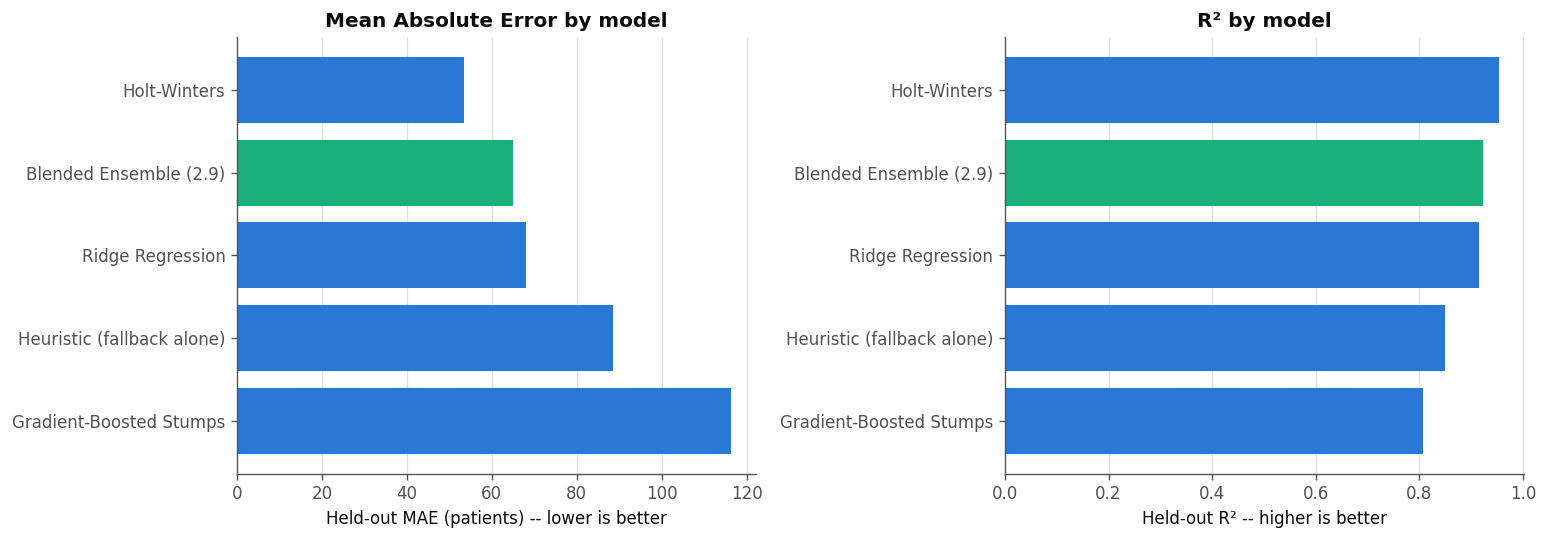

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
order = results_df.index.tolist()
colors = [C["blue"] if m != "Blended Ensemble (2.9)" else C["aqua"] for m in order]

ax = axes[0]
ax.barh(order, results_df["MAE"], color=colors)
ax.set_xlabel("Held-out MAE (patients) -- lower is better")
ax.set_title("Mean Absolute Error by model", fontweight="bold", color=C["ink"])
ax.grid(axis="x", color=C["hair"])
ax.set_axisbelow(True)
ax.invert_yaxis()

ax = axes[1]
ax.barh(order, results_df["R2"], color=colors)
ax.set_xlabel("Held-out R² -- higher is better")
ax.set_title("R² by model", fontweight="bold", color=C["ink"])
ax.grid(axis="x", color=C["hair"])
ax.set_axisbelow(True)
ax.invert_yaxis()

plt.tight_layout()
plt.show()

**Reading this honestly.** The blended ensemble comfortably beats Ridge
Regression, Gradient-Boosted Stumps, and the heuristic fallback individually —
but it does **not** beat Holt-Winters alone on this particular dataset, where
Holt-Winters happens to be unusually well-matched to a demand pattern
dominated by one strong, stable weekly rhythm. This is a genuine result, not
smoothed over: blending trades away a small amount of accuracy versus the
single best model *in hindsight*, in exchange for not needing that hindsight
in the first place. A hospital where the dominant demand pattern is less
stable, or where the linear or interaction effects captured by Ridge
Regression and boosted stumps matter more, would tell a different story — and
MediShift has no way of knowing in advance, for a hospital it hasn't seen yet,
which model will turn out to be the strongest. Accuracy-weighting is the
system hedging against exactly that uncertainty, rather than betting the
entire forecast on one model's specific strength.

## 5. The Day-of-Week Factor (Equation 2.10)

Equation 2.9 blends models for a *single* shift record. But Chapter 3's roster
needs one forecast for **every day** of its Monday-through-Sunday template —
Ridge Regression and boosted stumps already learn a genuine Monday-versus-
Friday pattern through their cyclic day-of-week feature, and Holt-Winters
carries it natively in its 21-slot seasonal array (Notebook 3, Section 7). The
heuristic has no such learned signal of its own, so it is adjusted by an
empirical factor from the historical, day-level dataset:

$$
\phi_d = \operatorname{clip}\!\left(\frac{\bar y_d}{\bar y},\; 0.8,\; 1.25\right), \qquad d \in \{\text{Mon},\dots,\text{Sun}\},
\tag{2.10}
$$

where $\bar y_d$ is the historical average on weekday $d$ and $\bar y$ the
overall average. The clip to $[0.8, 1.25]$ keeps a single outlier day from
swinging its weekday's target by more than about a quarter.

In [6]:
train = full.iloc[:SPLIT]   # phi_d computed only from training history -- no leakage
day_avg = train.groupby("weekday")["patient_inflow"].mean()
overall_avg = train["patient_inflow"].mean()
phi = (day_avg / overall_avg).clip(0.8, 1.25)

phi_df = pd.DataFrame({
    "weekday": ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"],
    "phi_d": phi.values,
})
phi_df

,weekday,phi_d
0,Mon,1.11
1,Tue,1.04
2,Wed,1.02
3,Thu,1.01
4,Fri,1.04
5,Sat,0.96
6,Sun,0.81


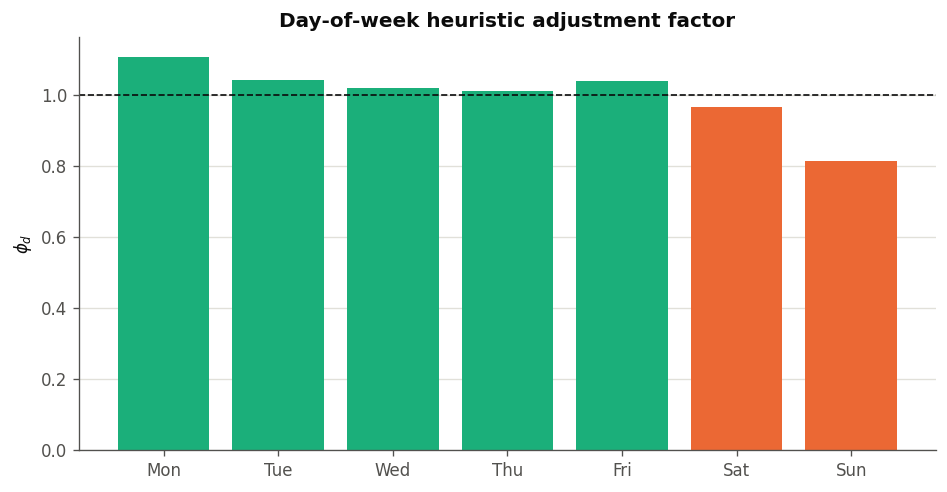

In [7]:
fig, ax = plt.subplots(figsize=(8, 4.2))
bar_colors = [C["aqua"] if v >= 1 else C["orange"] for v in phi_df["phi_d"]]
ax.bar(phi_df["weekday"], phi_df["phi_d"], color=bar_colors)
ax.axhline(1.0, color=C["ink"], lw=1, linestyle="--")
ax.set_ylabel(r"$\phi_d$")
ax.set_title("Day-of-week heuristic adjustment factor", fontweight="bold", color=C["ink"])
ax.grid(axis="y", color=C["hair"])
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

Weekdays run at or above the historical average, and both weekend days run
below it — Sunday markedly so. This is exactly the kind of structural pattern
the heuristic, on its own, has no way to see; $\phi_d$ is what lets it
participate honestly in a day-specific roster forecast instead of applying
one flat, day-blind adjustment everywhere.

## 6. From Held-Out Accuracy to a Full Roster-Week Forecast (Equation 2.11)

$$
\hat y_d = 0.6\big(\lambda_{\text{ridge}}\hat y_{\text{ridge},d} + \lambda_{\text{boosted}}\hat y_{\text{boosted},d} + \lambda_{\text{holt}}\hat y_{\text{holt},d}\big)
         + 0.4\,\big(\phi_d \cdot \hat y_{\text{heuristic}}\big), \qquad d \in \{\text{Mon},\dots,\text{Sun}\}.
\tag{2.11}
$$

This is the forecast Chapter 3 actually uses. Producing it means giving every
model a genuine forecast for the *same* upcoming 7-day, 21-shift roster week —
Holt-Winters already does this natively (Notebook 3, Section 7); Ridge
Regression and Gradient-Boosted Stumps are refit here on the **full** 3-year
history (the standard last step before forecasting forward in production) and
then evaluated recursively, shift by shift, feeding each model's own previous
prediction back in as the "most recent" data point for its rolling-average
feature, since the real values do not exist yet.

In [8]:
RIDGE_FEATURES = ["shift_morning", "shift_evening", "weather_rain", "weather_extreme",
                   "holiday", "local_event", "rolling_avg_7", "day_sin", "day_cos"]
BOOST_FEATURES = RIDGE_FEATURES + ["month_cos"]

full["rolling_avg_7"] = full["patient_inflow"].shift(1).rolling(7, min_periods=1).mean()
full["rolling_avg_7"] = full["rolling_avg_7"].fillna(full["patient_inflow"].mean())
full["day_sin"] = np.sin(2 * np.pi * full["weekday"] / 7)
full["day_cos"] = np.cos(2 * np.pi * full["weekday"] / 7)
full["month_cos"] = np.cos(2 * np.pi * (full["month"] - 1) / 12)
full["shift_morning"] = (full["shift_type"] == "Morning").astype(float)
full["shift_evening"] = (full["shift_type"] == "Evening").astype(float)
full["weather_rain"] = (full["weather"] == "Rain").astype(float)
full["weather_extreme"] = (full["weather"] == "Extreme Heat").astype(float)
full["holiday_f"] = full["is_holiday"].astype(float)
full["local_event_f"] = full["is_local_event"].astype(float)

def recency_weights(n_train, half_life_records=90):
    d = 0.5 ** (1.0 / half_life_records)
    i = np.arange(n_train)
    return d ** (n_train - 1 - i)

# --- refit Ridge on the FULL history ---
X_ridge_full = np.hstack([np.ones((N, 1)), full[["shift_morning", "shift_evening",
    "weather_rain", "weather_extreme", "holiday_f", "local_event_f",
    "rolling_avg_7", "day_sin", "day_cos"]].values])
y_full = full["patient_inflow"].values.astype(float)
w_full = recency_weights(N)
sw = np.sqrt(w_full)
beta_full = np.linalg.solve((X_ridge_full * sw[:, None]).T @ (X_ridge_full * sw[:, None]) + 1.0 * np.eye(X_ridge_full.shape[1]),
                             (X_ridge_full * sw[:, None]).T @ (y_full * sw))

# --- refit Gradient-Boosted Stumps on the FULL history ---
def weighted_mean(v, w):
    return np.sum(v * w) / np.sum(w)

def fit_stump(X, r, w, max_thresholds=40):
    n, p = X.shape
    best = None
    for j in range(p):
        col = X[:, j]
        candidates = np.unique(col)
        if len(candidates) > max_thresholds:
            candidates = np.unique(np.quantile(col, np.linspace(0, 1, max_thresholds)))
        for t in candidates:
            left = col <= t
            if 0 < left.sum() < n:
                right = ~left
                w_l, w_r = w[left], w[right]
                m_l = weighted_mean(r[left], w_l)
                m_r = weighted_mean(r[right], w_r)
                sse = np.sum(w_l * (r[left] - m_l) ** 2) + np.sum(w_r * (r[right] - m_r) ** 2)
                if best is None or sse < best[0]:
                    best = (sse, j, t, m_l, m_r)
    return best

X_boost_full = full[["shift_morning", "shift_evening", "weather_rain", "weather_extreme",
                      "holiday_f", "local_event_f", "rolling_avg_7", "day_sin", "day_cos", "month_cos"]].values
F0_full = weighted_mean(y_full, w_full)
pred_full = np.full(N, F0_full)
stumps_full = []
for m_round in range(30):
    resid = y_full - pred_full
    sse, j, t, m_l, m_r = fit_stump(X_boost_full, resid, w_full)
    stumps_full.append((j, t, m_l, m_r))
    pred_full = pred_full + 0.1 * np.where(X_boost_full[:, j] <= t, m_l, m_r)

print(f"Ridge refit on all {N:,} records. Boosted-stumps refit on all {N:,} records "
      f"({len(stumps_full)} stumps).")

Ridge refit on all 3,291 records. Boosted-stumps refit on all 3,291 records (30 stumps).


In [9]:
SHIFT_CYCLE = ["Morning", "Evening", "Night"]
last_date = full["date"].iloc[-1]
last_shift_idx = SHIFT_CYCLE.index(full["shift_type"].iloc[-1])

ridge_hist = list(full["patient_inflow"].values[-7:])
boost_hist = list(full["patient_inflow"].values[-7:])

cur_date, cur_idx = last_date, last_shift_idx
rows = []
for h in range(21):
    cur_idx += 1
    if cur_idx == 3:
        cur_idx = 0
        cur_date = cur_date + pd.Timedelta(days=1)
    shift_type = SHIFT_CYCLE[cur_idx]
    weekday = cur_date.weekday()

    roll_r = float(np.mean(ridge_hist[-7:]))
    roll_b = float(np.mean(boost_hist[-7:]))
    day_sin, day_cos = np.sin(2 * np.pi * weekday / 7), np.cos(2 * np.pi * weekday / 7)

    x_ridge = np.array([
        1.0,
        1.0 if shift_type == "Morning" else 0.0,
        1.0 if shift_type == "Evening" else 0.0,
        0.0, 0.0, 0.0, 0.0,   # weather / holiday / local event -- unknowable this far ahead
        roll_r, day_sin, day_cos,
    ])
    pred_ridge = float(x_ridge @ beta_full)

    x_boost = np.array([
        1.0 if shift_type == "Morning" else 0.0,
        1.0 if shift_type == "Evening" else 0.0,
        0.0, 0.0, 0.0, 0.0,
        roll_b, day_sin, day_cos,
        np.cos(2 * np.pi * (cur_date.month - 1) / 12),
    ])
    pred_boost = F0_full
    for (j, t, m_l, m_r) in stumps_full:
        pred_boost += 0.1 * (m_l if x_boost[j] <= t else m_r)

    ridge_hist.append(pred_ridge)
    boost_hist.append(pred_boost)
    rows.append({"date": cur_date, "weekday": weekday, "shift_type": shift_type,
                 "ridge": pred_ridge, "boosted": pred_boost})

roster_week = pd.DataFrame(rows)
roster_week.head(6)

,date,weekday,shift_type,ridge,boosted
0,2026-08-05,2,Morning,"1,082.44","1,030.10"
1,2026-08-05,2,Evening,603.95,533.22
2,2026-08-05,2,Night,320.57,428.23
3,2026-08-06,3,Morning,"1,059.13","1,030.10"
4,2026-08-06,3,Evening,576.85,533.22
5,2026-08-06,3,Night,295.45,428.23


Holt-Winters' own next-week forecast is reproduced here identically to
Notebook 3, Section 7, so all three fitted models forecast the exact same 21
shifts.

In [10]:
def holt_winters_fit_predict(y, alpha=0.35, beta=0.12, gamma=0.20, m=21):
    n = len(y)
    level = y[0]
    trend = (y[m] - y[0]) / m if n > m else 0.0
    season = np.zeros(m)
    for i in range(min(m, n)):
        season[i] = y[i] - level
    levels_, trends_, seasonals_ = np.zeros(n), np.zeros(n), np.zeros(n)
    for t in range(n):
        s_idx = t % m
        new_level = alpha * (y[t] - season[s_idx]) + (1 - alpha) * (level + trend)
        new_trend = beta * (new_level - level) + (1 - beta) * trend
        season[s_idx] = gamma * (y[t] - new_level) + (1 - gamma) * season[s_idx]
        level, trend = new_level, new_trend
        levels_[t], trends_[t], seasonals_[t] = level, trend, season[s_idx]
    return levels_, trends_, seasonals_

M = 21
levels_hw, trends_hw, seasonals_hw = holt_winters_fit_predict(y_full, 0.35, 0.12, 0.20, M)
final_season_array = np.zeros(M)
for t in range(N - M, N):
    final_season_array[t % M] = seasonals_hw[t]
last_slot = (N - 1) % M
horizon = np.arange(1, M + 1)
seasonal_idx = (last_slot + horizon) % M
holt_forecast_next_week = levels_hw[-1] + horizon * trends_hw[-1] + final_season_array[seasonal_idx]

roster_week["holt"] = holt_forecast_next_week
roster_week.head(6)

,date,weekday,shift_type,ridge,boosted,holt
0,2026-08-05,2,Morning,"1,082.44","1,030.10","1,087.97"
1,2026-08-05,2,Evening,603.95,533.22,596.20
2,2026-08-05,2,Night,320.57,428.23,305.63
3,2026-08-06,3,Morning,"1,059.13","1,030.10","1,088.54"
4,2026-08-06,3,Evening,576.85,533.22,619.23
5,2026-08-06,3,Night,295.45,428.23,317.16


And the heuristic's own forecast for the same week, day-adjusted by $\phi_d$
(Equation 2.10) exactly as Equation 2.11 specifies — no anomalies are assumed
known this far in advance, so the anomaly multiplier is left at 1.

In [11]:
heur_hist = {s: list(full.loc[full["shift_type"] == s, "patient_inflow"].values[-3:]) for s in SHIFT_CYCLE}
baseline_avg = {s: full.loc[full["shift_type"] == s, "patient_inflow"].mean() for s in SHIFT_CYCLE}

heuristic_vals, phi_vals = [], []
for _, row in roster_week.iterrows():
    s = row["shift_type"]
    recent3 = np.mean(heur_hist[s][-3:])
    base = 0.75 * recent3 + 0.25 * baseline_avg[s]
    heuristic_vals.append(base)          # no anomaly flags assumed known in advance
    phi_vals.append(phi.loc[row["weekday"]])
    heur_hist[s].append(base)

roster_week["heuristic"] = heuristic_vals
roster_week["phi_d"] = phi_vals

fitted_blend_week = (lam["ridge"] * roster_week["ridge"]
                      + lam["boosted"] * roster_week["boosted"]
                      + lam["holt"] * roster_week["holt"])
roster_week["blended_forecast"] = np.round(
    0.6 * fitted_blend_week + 0.4 * (roster_week["phi_d"] * roster_week["heuristic"])
).astype(int)

roster_week["day"] = roster_week["date"].dt.strftime("%a")
display_cols = ["date", "day", "shift_type", "ridge", "boosted", "holt", "heuristic", "phi_d", "blended_forecast"]
roster_week[display_cols]

,date,day,shift_type,ridge,boosted,holt,heuristic,phi_d,blended_forecast
0,2026-08-05,Wed,Morning,"1,082.44","1,030.10","1,087.97","1,079.27",1.02,1084
1,2026-08-05,Wed,Evening,603.95,533.22,596.20,618.16,1.02,604
2,2026-08-05,Wed,Night,320.57,428.23,305.63,270.32,1.02,312
3,2026-08-06,Thu,Morning,"1,059.13","1,030.10","1,088.54","1,112.84",1.01,1090
4,2026-08-06,Thu,Evening,576.85,533.22,619.23,635.95,1.01,609
5,2026-08-06,Thu,Night,295.45,428.23,317.16,279.90,1.01,313
6,2026-08-07,Fri,Morning,"1,024.01","1,030.10","1,192.21","1,083.55",1.04,1111
7,2026-08-07,Fri,Evening,541.46,533.22,639.84,617.68,1.04,607
8,2026-08-07,Fri,Night,261.45,428.23,343.41,273.88,1.04,313
9,2026-08-08,Sat,Morning,"1,001.63","1,030.10","1,083.91","1,066.19",0.96,1038


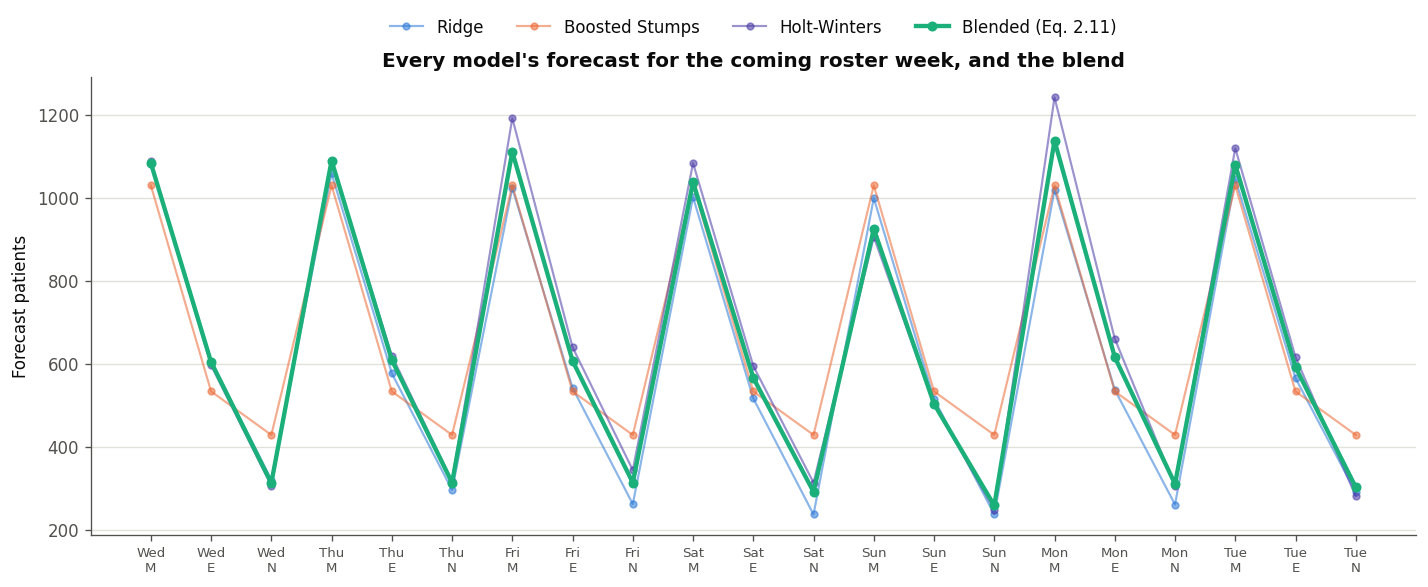

In [12]:
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(roster_week))
labels = [f"{d}\n{s[0]}" for d, s in zip(roster_week["day"], roster_week["shift_type"])]

ax.plot(x, roster_week["ridge"], color=C["blue"], lw=1.3, marker="o", ms=4, alpha=0.55, label="Ridge")
ax.plot(x, roster_week["boosted"], color=C["orange"], lw=1.3, marker="o", ms=4, alpha=0.55, label="Boosted Stumps")
ax.plot(x, roster_week["holt"], color=C["violet"], lw=1.3, marker="o", ms=4, alpha=0.55, label="Holt-Winters")
ax.plot(x, roster_week["blended_forecast"], color=C["aqua"], lw=2.6, marker="o", ms=5, label="Blended (Eq. 2.11)")

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=8)
ax.set_ylabel("Forecast patients")
ax.set_title("Every model's forecast for the coming roster week, and the blend", fontweight="bold", color=C["ink"])
ax.legend(frameon=False, ncol=4, loc="upper center", bbox_to_anchor=(0.5, 1.16))
ax.grid(axis="y", color=C["hair"])
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

**Reading the chart.** All four lines trace the same Morning-high /
Evening-mid / Night-low sawtooth — every model, fitted completely differently,
independently recovers the dominant pattern in the data. The blended forecast
(the thick teal line) sits close to Holt-Winters, its most heavily-weighted
component, while still being visibly pulled toward the other three signals
rather than reproducing any single model exactly — precisely what a weighted
blend is supposed to do. This seven-day, twenty-one-shift table is
`target_{d,s}`'s starting point in Chapter 3's staffing model: each entry
becomes, via the two-ratio model (Section 3.1), a minimum-safe and an
ideal headcount for every category, shift, and day of the week.

## 7. Pipeline Recap (Report Figure 2.1 / Algorithm 2.1)

Every notebook in this forecasting sequence maps onto one stage of the same
pipeline:

| Stage | What happens | Notebook |
|---|---|---|
| 1 | Load the 3-year shift dataset, engineer features | 1, 2, 3 |
| 2 | Fit Ridge Regression (closed-form, recency-weighted) | 1 |
| 3 | Fit Gradient-Boosted Stumps (30 rounds, additive) | 2 |
| 4 | Fit Holt-Winters (sequential level/trend/season) | 3 |
| 5 | Weight each fitted model by inverse held-out MAE | 4, Section 2 |
| 6 | Compute the heuristic fallback + day-of-week factor $\phi_d$ | 4, Sections 3 & 5 |
| 7 | Blend fitted models (60%) with the heuristic (40%), per day | 4, Section 6 |
| 8 | Hand the resulting `target_{d,s}` table to the staffing model | *Notebook 5* |

This is Algorithm 2.1 from the report, reproduced end-to-end on real data
rather than described in the abstract: every one of MediShift's forecasting
claims in this notebook series is a number computed from the 3,291-record
shift dataset, not an illustrative figure.